<a href="https://colab.research.google.com/github/paul-rl/QLoRa/blob/feature%2Fmt-bench/mt_bench_eval_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notes on FastChat Compatibility
- FastChat's `OPENAI_MODEL_LIST` in `model_adapter.py` was patched to accept
  `gpt-4.1` as a judge model (the original `gpt-4` has been retired by OpenAI)
- GPT-4 reference answers were copied to `gpt-4.1.jsonl` for the same reason
- These patches are applied automatically by cells in Section 6 of the notebook

# MT-Bench Evaluation — QLoRA LLaMA-3-8B Experiments

This notebook evaluates **three QLoRA fine-tuned LLaMA-3-8B variants** using MT-Bench:

| Model ID | Description |
|---|---|
| `llama3_8b_baseline` | Baseline (no quantization / standard LoRA) |
| `llama3_8b_fp4` | QLoRA with FP4 quantization |
| `llama3_8b_nf4` | QLoRA with NF4 quantization |

MT-Bench is a fixed benchmark of 80 multi-turn questions (2 turns each, 160 generations per model) across 8 categories: writing, roleplay, extraction, math, coding, reasoning, STEM, and humanities. GPT-4.1 judges each response on a 1–10 scale.

**Pipeline:** Install → Merge adapters → Generate answers (×3 models) → GPT-4.1 judging → Compare results

**Repo structure:**
```
QLoRa/src/qlora_experiments/
├── llama3_8b_baseline/final_adapter/
│   ├── adapter_config.json
│   ├── adapter_model.safetensors
│   ├── chat_template.json
│   ├── tokenizer.json
│   └── tokenizer_config.json
├── llama3_8b_fp4/final_adapter/
│   └── (same structure)
├── llama3_8b_nf4/final_adapter/
│   └── (same structure)
├── comparison_summary.json
└── qlora_training.py
```

---

## 1. Installation

In [1]:
# Clone FastChat
!git clone https://github.com/lm-sys/FastChat.git
%cd FastChat
!pip install -e ".[model_worker,llm_judge]"

Cloning into 'FastChat'...
remote: Enumerating objects: 8535, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 8535 (delta 96), reused 40 (delta 39), pack-reused 8413 (from 3)
Receiving objects: 100% (8535/8535), 34.54 MiB | 34.04 MiB/s, done.
Resolving deltas: 100% (6485/6485), done.
/content/FastChat
Obtaining file:///content/FastChat
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.6/700.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.0/807.0 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
# Install dependencies
!pip install openai pandas tabulate matplotlib peft bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.8 MB/s eta 0:00:00


In [3]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [4]:
# Clone the QLoRA repo with the trained adapters
%cd /content
!git clone -b feature/training-and-adapters https://github.com/paul-rl/QLoRa.git

/content
Cloning into 'QLoRa'...
remote: Enumerating objects: 62, done.
remote: Total 62 (delta 0), reused 0 (delta 0), pack-reused 62 (from 1)
Receiving objects: 100% (62/62), 35.36 MiB | 30.89 MiB/s, done.
Resolving deltas: 100% (14/14), done.


## 2. Configuration

In [16]:
import os
import json

# =============================================================================
# CONFIGURATION
# =============================================================================

# Base model — using Unsloth's ungated mirror (no HF approval needed)
# If adapter_config.json shows the Instruct variant, change to "unsloth/llama-3-8b-Instruct"
BASE_MODEL = "unsloth/llama-3-8b"

# Root path to experiment directories
REPO_ROOT = "/content/QLoRa/qlora_experiments"

# The three experiments — each adapter lives under final_adapter/
EXPERIMENTS = {
    "llama3_8b_baseline": os.path.join(REPO_ROOT, "llama3_8b_baseline", "final_adapter"),
    "llama3_8b_fp4":      os.path.join(REPO_ROOT, "llama3_8b_fp4", "final_adapter"),
    "llama3_8b_nf4":      os.path.join(REPO_ROOT, "llama3_8b_nf4", "final_adapter"),
}

# Where to save merged models
MERGED_DIR = "/content/merged_models"

# GPU config
NUM_GPUS_PER_MODEL = 1
NUM_GPUS_TOTAL = 1

# OpenAI API key for GPT-4 judging
# Option A: Colab Secrets (recommended — add key via the key icon in left sidebar)
from google.colab import userdata
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

# Option B: Hardcode (less secure, uncomment below and comment out Option A)
# OPENAI_API_KEY = "sk-..."

# Judge model: "gpt-4o" (~$3/model) or "gpt-4o-mini" (~$0.50/model, noisier)
JUDGE_MODEL = "gpt-4.1"
PARALLEL_CALLS = 2

# FastChat paths
LLM_JUDGE_DIR = "/content/FastChat/fastchat/llm_judge"

print("Configuration:")
print(f"  Base model:    {BASE_MODEL}")
print(f"  Experiments:   {list(EXPERIMENTS.keys())}")
print(f"  Judge:         {JUDGE_MODEL}")

Configuration:
  Base model:    unsloth/llama-3-8b
  Experiments:   ['llama3_8b_baseline', 'llama3_8b_fp4', 'llama3_8b_nf4']
  Judge:         gpt-4.1


## 3. Inspect Adapter Files

Verify each experiment's `final_adapter/` directory has the expected files and check the adapter config.

**Important:** Check the `Base model` field below. If it says `Meta-Llama-3-8B-Instruct`, update `BASE_MODEL` above to `"unsloth/llama-3-8b-Instruct"`.

In [6]:
for name, adapter_path in EXPERIMENTS.items():
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"Path:       {adapter_path}")
    print(f"{'='*60}")

    if not os.path.isdir(adapter_path):
        print("  ERROR: Directory not found!")
        continue

    files = os.listdir(adapter_path)
    print(f"  Files: {files}")

    # Read adapter config
    config_path = os.path.join(adapter_path, "adapter_config.json")
    if os.path.isfile(config_path):
        with open(config_path, "r") as f:
            config = json.load(f)
        print(f"  Base model:     {config.get('base_model_name_or_path', 'N/A')}")
        print(f"  LoRA rank (r):  {config.get('r', 'N/A')}")
        print(f"  LoRA alpha:     {config.get('lora_alpha', 'N/A')}")
        print(f"  LoRA dropout:   {config.get('lora_dropout', 'N/A')}")
        print(f"  Target modules: {config.get('target_modules', 'N/A')}")
    else:
        print("  WARNING: No adapter_config.json found!")

    # Check for chat template
    chat_tpl_path = os.path.join(adapter_path, "chat_template.json")
    if os.path.isfile(chat_tpl_path):
        with open(chat_tpl_path, "r") as f:
            chat_tpl = json.load(f)
        print(f"  Chat template:  Found ({list(chat_tpl.keys())})")
    else:
        print("  Chat template:  Not found (will use FastChat default)")

    # Check for weights
    has_safetensors = any(f.endswith(".safetensors") for f in files)
    has_bin = any(f.endswith(".bin") for f in files)
    print(f"  Weights format: {'safetensors' if has_safetensors else 'bin' if has_bin else 'NOT FOUND'}")


Experiment: llama3_8b_baseline
Path:       /content/QLoRa/qlora_experiments/llama3_8b_baseline/final_adapter
  Files: ['tokenizer.json', 'adapter_model.safetensors', 'tokenizer_config.json', 'chat_template.jinja', 'README.md', 'adapter_config.json']
  Base model:     ./Meta-Llama-3-8B-Instruct
  LoRA rank (r):  8
  LoRA alpha:     16
  LoRA dropout:   0.05
  Target modules: ['k_proj', 'q_proj', 'o_proj', 'v_proj']
  Chat template:  Not found (will use FastChat default)
  Weights format: safetensors

Experiment: llama3_8b_fp4
Path:       /content/QLoRa/qlora_experiments/llama3_8b_fp4/final_adapter
  Files: ['tokenizer.json', 'adapter_model.safetensors', 'tokenizer_config.json', 'chat_template.jinja', 'README.md', 'adapter_config.json']
  Base model:     ./Meta-Llama-3-8B-Instruct
  LoRA rank (r):  8
  LoRA alpha:     16
  LoRA dropout:   0.05
  Target modules: ['k_proj', 'q_proj', 'o_proj', 'v_proj']
  Chat template:  Not found (will use FastChat default)
  Weights format: safetensors


## 4. Merge Adapters with Base Model

FastChat expects a standard HuggingFace model directory. We merge each PEFT adapter into the base LLaMA-3-8B and save a full copy.

The tokenizer and chat template from each adapter are copied into the merged model so it retains the correct prompt format.

In [7]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
import gc
import shutil

os.makedirs(MERGED_DIR, exist_ok=True)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

for name, adapter_path in EXPERIMENTS.items():
    merged_path = os.path.join(MERGED_DIR, name)

    if os.path.isdir(merged_path) and any(
        f.endswith(".safetensors") for f in os.listdir(merged_path)
    ):
        print(f"[{name}] Already merged, skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Merging: {name}")
    print(f"{'='*60}")

    # Load base model
    print(f"  Loading base model: {BASE_MODEL}")
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype=torch.float16,
        device_map="auto",
        quantization_config=None,  # <--- Forces it to ignore the 4-bit config
    )

    # Load tokenizer from the base model
    print(f"  Loading tokenizer from base model: {BASE_MODEL}")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

    # Load and merge adapter
    print(f"  Loading adapter...")
    model = PeftModel.from_pretrained(base_model, adapter_path)

    print(f"  Merging weights...")
    # Remove the .dequantize() line entirely!
    model = model.merge_and_unload()

    print(f"  Saving to: {merged_path}")
    os.makedirs(merged_path, exist_ok=True)
    model.save_pretrained(merged_path)
    tokenizer.save_pretrained(merged_path)

    chat_tpl_src = os.path.join(adapter_path, "chat_template.json")
    if os.path.isfile(chat_tpl_src):
        shutil.copy2(chat_tpl_src, os.path.join(merged_path, "chat_template.json"))
        print(f"  Copied chat_template.json")

    del model, base_model
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  Done.\n")

print("All adapters merged.")


Merging: llama3_8b_baseline
  Loading base model: unsloth/llama-3-8b


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

...

  Done.


Merging: llama3_8b_nf4
  Loading base model: unsloth/llama-3-8b


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  Loading tokenizer from base model: unsloth/llama-3-8b
  Loading adapter...
  Merging weights...
  Saving to: /content/merged_models/llama3_8b_nf4


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Done.

All adapters merged.


## 5. Generate Model Answers (Step 1 of MT-Bench)

Run each merged model against all 80 MT-Bench questions (2 turns each = 160 generations per model).

**Estimated time:** ~20–40 min per model on a T4, ~10–15 min on an A100.

In [8]:
%cd {LLM_JUDGE_DIR}

for name in EXPERIMENTS.keys():
    merged_path = os.path.join(MERGED_DIR, name)
    answer_file = os.path.join(
        LLM_JUDGE_DIR, "data", "mt_bench", "model_answer", f"{name}.jsonl"
    )

    # Skip if answers already generated
    if os.path.isfile(answer_file):
        print(f"[{name}] Answers already exist, skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Generating answers: {name}")
    print(f"{'='*60}")

    !python gen_model_answer.py \
        --model-path {merged_path} \
        --model-id {name} \
        --num-gpus-per-model {NUM_GPUS_PER_MODEL} \
        --num-gpus-total {NUM_GPUS_TOTAL}

/content/FastChat/fastchat/llm_judge

Generating answers: llama3_8b_baseline
/content/FastChat/fastchat/llm_judge/common.py:34: SyntaxWarning: invalid escape sequence '\['
  two_score_pattern = re.compile("\[\[(\d+\.?\d*),\s?(\d+\.?\d*)\]\]")
/content/FastChat/fastchat/llm_judge/common.py:35: SyntaxWarning: invalid escape sequence '\['
  two_score_pattern_backup = re.compile("\[(\d+\.?\d*),\s?(\d+\.?\d*)\]")
/content/FastChat/fastchat/llm_judge/common.py:36: SyntaxWarning: invalid escape sequence '\['
  one_score_pattern = re.compile("\[\[(\d+\.?\d*)\]\]")
/content/FastChat/fastchat/llm_judge/common.py:37: SyntaxWarning: invalid escape sequence '\['
  one_score_pattern_backup = re.compile("\[(\d+\.?\d*)\]")
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/content/FastChat/fastchat/model/model_chatglm.py:32: SyntaxWarning: invalid escape sequence '\?'
  ["\?", "？"],
Output to data/mt_bench/model_answer/llama3_8

In [9]:
# Verify all answer files were generated
print("Answer file check:")
for name in EXPERIMENTS.keys():
    answer_file = os.path.join(
        LLM_JUDGE_DIR, "data", "mt_bench", "model_answer", f"{name}.jsonl"
    )
    if os.path.isfile(answer_file):
        with open(answer_file, "r") as f:
            count = sum(1 for _ in f)
        print(f"  {name}: {count} answers")
    else:
        print(f"  {name}: MISSING!")

Answer file check:
  llama3_8b_baseline: 80 answers
  llama3_8b_fp4: 80 answers
  llama3_8b_nf4: 80 answers


## 6. Generate GPT-4 Judgments (Step 2 of MT-Bench)

Send all model answers to GPT-4 for scoring. Uses single-answer grading mode (recommended default) where GPT-4 grades each response independently on a 1–10 scale.

**Estimated cost:** ~$3 per model with `gpt-4o` ($9 total for 3 models), or ~$1.50 total with `gpt-4o-mini`.

In [23]:
# Patch FastChat to accept gpt-4.1 as a valid OpenAI model
adapter_file = "/content/FastChat/fastchat/model/model_adapter.py"

with open(adapter_file, "r") as f:
    content = f.read()

if "gpt-4.1" not in content:
    content = content.replace(
        'OPENAI_MODEL_LIST = (',
        'OPENAI_MODEL_LIST = (\n    "gpt-4.1",\n    "gpt-4.1-mini",\n    "gpt-5.1",\n'
    )
    with open(adapter_file, "w") as f:
        f.write(content)
    print("Patched model_adapter.py — added gpt-4.1 to OPENAI_MODEL_LIST.")
else:
    print("Already patched.")

Patched model_adapter.py — added gpt-4.1 to OPENAI_MODEL_LIST.


In [25]:
import shutil

ref_dir = os.path.join(LLM_JUDGE_DIR, "data", "mt_bench", "reference_answer")
src = os.path.join(ref_dir, "gpt-4.jsonl")
dst = os.path.join(ref_dir, "gpt-4.1.jsonl")

if os.path.isfile(src) and not os.path.isfile(dst):
    shutil.copy2(src, dst)
    print(f"Copied reference answers: gpt-4.jsonl -> gpt-4.1.jsonl")

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

model_list = " ".join(EXPERIMENTS.keys())

!python gen_judgment.py \
    --model-list {model_list} \
    --judge-model {JUDGE_MODEL} \
    --parallel {PARALLEL_CALLS}

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Stats:
{
    "bench_name": "mt_bench",
    "mode": "single",
    "judge": "gpt-4.1",
    "baseline": null,
    "model_list": [
        "llama3_8b_baseline",
        "llama3_8b_fp4",
        "llama3_8b_nf4"
    ],
    "total_num_questions": 80,
    "total_num_matches": 480,
    "output_path": "data/mt_bench/model_judgment/gpt-4.1_single.jsonl"
}
Press Enter to confirm...
  0% 0/480 [00:00<?, ?it/s]question: 86, turn: 1, model: llama3_8b_baseline, score: 7, judge: ('gpt-4.1', 'single-v1')
  0% 1/480 [00:05<42:27,  5.32s/it]question: 152, turn: 1, model: llama3_8b_fp4, score: 6, judge: ('gpt-4.1', 'single-v1')
  0% 2/480 [00:05<19:53,  2.50s/it]question: 88, turn: 2, model: llama3_8b_nf4, score: 2, judge: ('gpt-4.1', 'single-v1-multi-turn')
question: 107, turn: 1, model: llama3_8b_nf4, score: 10, judge: ('gpt-4.1', 'single-math-v1')
<class 'openai.error.RateLimitErr

In [32]:
# Verify judgments
judgment_file = os.path.join(
    LLM_JUDGE_DIR, "data", "mt_bench", "model_judgment", "gpt-4.1_single.jsonl"
)
if os.path.isfile(judgment_file):
    with open(judgment_file, "r") as f:
        judgments = [json.loads(line) for line in f]
    for name in EXPERIMENTS.keys():
        count = sum(1 for j in judgments if j.get("model") == name)
        print(f"  {name}: {count} judgments")
else:
    print("Judgment file not found — check gen_judgment.py output above for errors.")

  llama3_8b_baseline: 160 judgments
  llama3_8b_fp4: 160 judgments
  llama3_8b_nf4: 160 judgments


## 7. Display Results (Step 3 of MT-Bench)

Use FastChat's built-in `show_result.py` to display scores by turn and overall average.

In [34]:
!python show_result.py --model-list {model_list} --judge-model {JUDGE_MODEL}

Mode: single
Input file: data/mt_bench/model_judgment/gpt-4.1_single.jsonl

########## First turn ##########
                          score
model              turn        
llama3_8b_baseline 1     5.1625
llama3_8b_fp4      1     4.3625
llama3_8b_nf4      1     4.3000

########## Second turn ##########
                          score
model              turn        
llama3_8b_baseline 2     3.3625
llama3_8b_fp4      2     2.5000
llama3_8b_nf4      2     2.4125

########## Average ##########
                      score
model                      
llama3_8b_baseline  4.26250
llama3_8b_fp4       3.43125
llama3_8b_nf4       3.35625


## 8. Detailed Comparison Analysis

Parse the judgment file and produce a full breakdown: per-category scores, turn comparison, and visualizations for the project report.

In [45]:
import json
import os
import pandas as pd

# 1. Load Question Metadata
question_file = os.path.join(LLM_JUDGE_DIR, "data", "mt_bench", "question.jsonl")
question_map = {}
with open(question_file, "r") as f:
    for line in f:
        q = json.loads(line)
        question_map[q["question_id"]] = q["category"]

# 2. Load Judgments and Map Category
records = []
with open(judgment_file, "r") as f:
    for line in f:
        j = json.loads(line)
        if j.get("model") in EXPERIMENTS and j.get("score") != -1:
            q_id = j["question_id"]
            records.append({
                "model": j["model"],
                "question_id": q_id,
                "category": question_map.get(q_id, "unknown"), # Map here!
                "turn": j["turn"],
                "score": j["score"],
            })

df = pd.DataFrame(records)
df.head()

,model,question_id,category,turn,score
0,llama3_8b_baseline,86,writing,1,7
1,llama3_8b_fp4,152,humanities,1,6
2,llama3_8b_nf4,88,writing,2,2
3,llama3_8b_nf4,107,reasoning,1,10
4,llama3_8b_baseline,158,humanities,1,7


In [46]:
# Overall average scores
print("="*60)
print("OVERALL AVERAGE SCORES")
print("="*60)
overall = df.groupby("model")["score"].mean().round(2).sort_values(ascending=False)
for model, score in overall.items():
    print(f"  {model:<25s} {score:.2f}")

OVERALL AVERAGE SCORES
  llama3_8b_baseline        4.26
  llama3_8b_fp4             3.43
  llama3_8b_nf4             3.36


In [47]:
# Scores by turn
print("="*60)
print("SCORES BY TURN")
print("="*60)
turn_scores = df.groupby(["model", "turn"])["score"].mean().round(2).unstack()
turn_scores.columns = ["Turn 1", "Turn 2"]
turn_scores["Average"] = turn_scores.mean(axis=1).round(2)
print(turn_scores.sort_values("Average", ascending=False).to_string())

SCORES BY TURN
                    Turn 1  Turn 2  Average
model                                      
llama3_8b_baseline    5.16    3.36     4.26
llama3_8b_fp4         4.36    2.50     3.43
llama3_8b_nf4         4.30    2.41     3.36


In [48]:
# Scores by category (pivot table)
print("="*60)
print("SCORES BY CATEGORY")
print("="*60)
cat_scores = df.groupby(["model", "category"])["score"].mean().round(2).unstack()
print(cat_scores.to_string())

SCORES BY CATEGORY
category            coding  extraction  humanities  math  reasoning  roleplay  stem  writing
model                                                                                       
llama3_8b_baseline    3.45        4.95        5.60  1.75        4.2      4.85   5.0     4.30
llama3_8b_fp4         3.00        3.90        3.55  1.75        4.1      3.65   4.3     3.20
llama3_8b_nf4         3.45        3.25        3.90  1.70        4.1      3.60   3.8     3.05


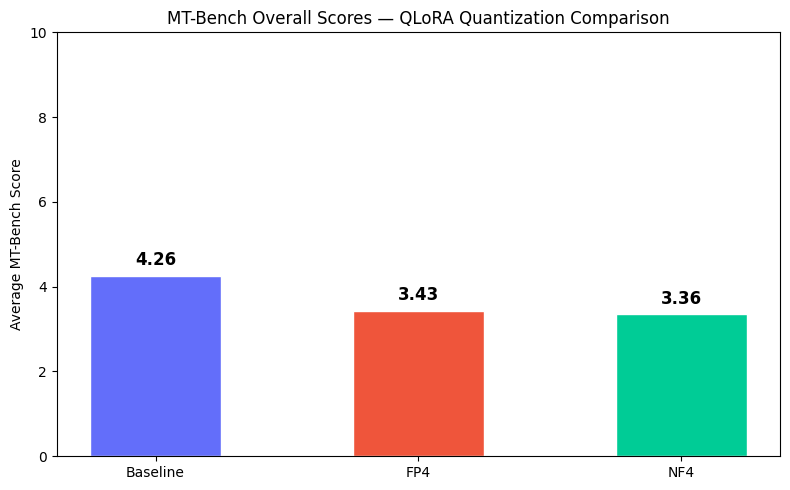

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Bar chart: overall scores side by side ----
model_names = list(EXPERIMENTS.keys())
display_names = ["Baseline", "FP4", "NF4"]
colors = ["#636EFA", "#EF553B", "#00CC96"]

avg_scores = [df[df["model"] == m]["score"].mean() for m in model_names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(display_names, avg_scores, color=colors, edgecolor="white", width=0.5)
ax.set_ylabel("Average MT-Bench Score")
ax.set_title("MT-Bench Overall Scores — QLoRA Quantization Comparison")
ax.set_ylim(0, 10)
for bar, val in zip(bars, avg_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.15, f"{val:.2f}",
            ha="center", va="bottom", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("mt_bench_overall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

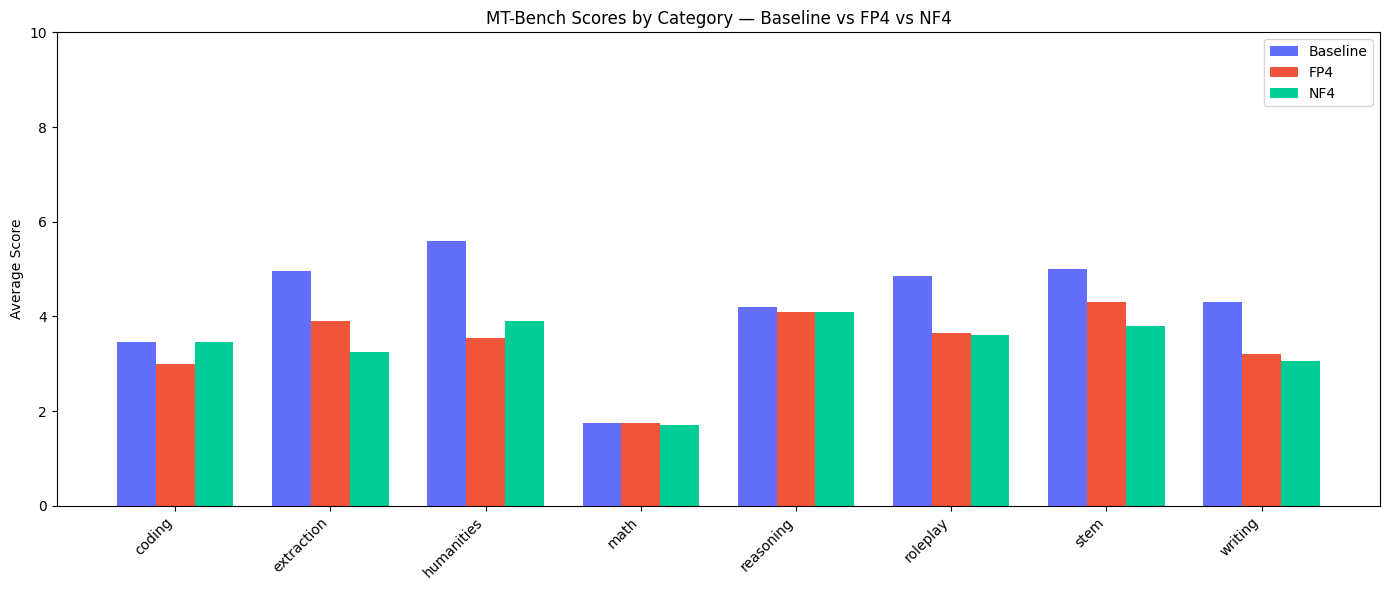

In [50]:
# ---- Grouped bar chart: per-category comparison ----
categories = sorted(df["category"].unique())
x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model, label, color) in enumerate(zip(model_names, display_names, colors)):
    scores = [df[(df["model"] == model) & (df["category"] == c)]["score"].mean()
              for c in categories]
    ax.bar(x + i * width, scores, width, label=label, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_ylabel("Average Score")
ax.set_title("MT-Bench Scores by Category — Baseline vs FP4 vs NF4")
ax.set_ylim(0, 10)
ax.legend()
plt.tight_layout()
plt.savefig("mt_bench_category_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

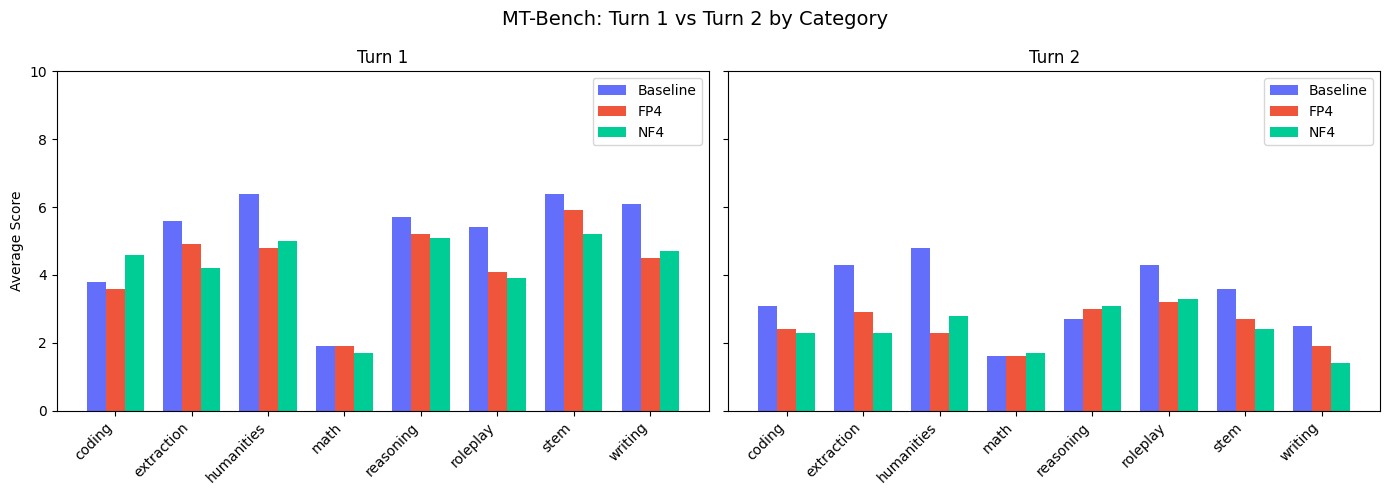

In [51]:
# ---- Turn 1 vs Turn 2 grouped comparison ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for turn_idx, ax in enumerate(axes, start=1):
    turn_df = df[df["turn"] == turn_idx]
    for i, (model, label, color) in enumerate(zip(model_names, display_names, colors)):
        scores = [turn_df[(turn_df["model"] == model) & (turn_df["category"] == c)]["score"].mean()
                  for c in categories]
        ax.bar(x + i * width, scores, width, label=label, color=color)
    ax.set_xticks(x + width)
    ax.set_xticklabels(categories, rotation=45, ha="right")
    ax.set_title(f"Turn {turn_idx}")
    ax.set_ylim(0, 10)
    ax.set_ylabel("Average Score" if turn_idx == 1 else "")
    ax.legend()

plt.suptitle("MT-Bench: Turn 1 vs Turn 2 by Category", fontsize=14)
plt.tight_layout()
plt.savefig("mt_bench_turn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

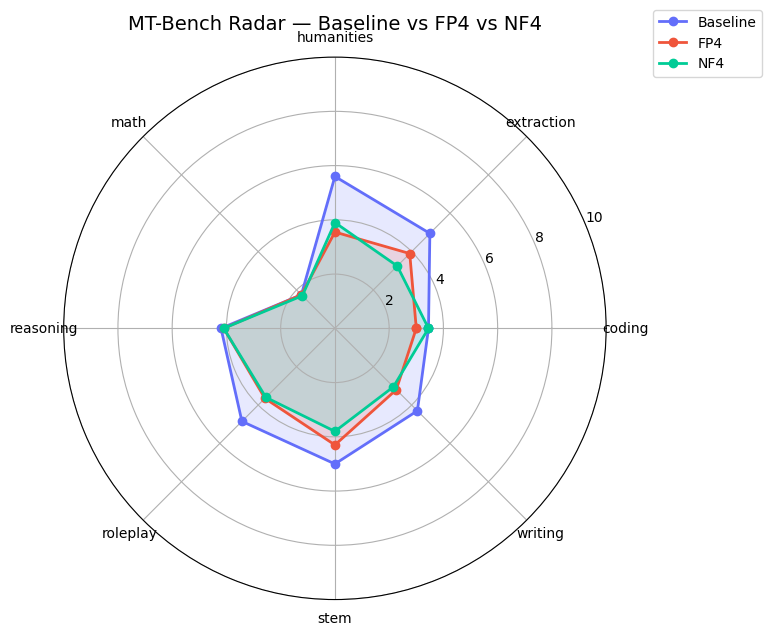

In [52]:
# ---- Radar chart: all three models overlaid ----
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model, label, color in zip(model_names, display_names, colors):
    scores = [df[(df["model"] == model) & (df["category"] == c)]["score"].mean()
              for c in categories]
    scores += scores[:1]  # close polygon
    ax.fill(angles, scores, alpha=0.15, color=color)
    ax.plot(angles, scores, "o-", color=color, linewidth=2, label=label)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 10)
ax.set_title("MT-Bench Radar — Baseline vs FP4 vs NF4", pad=20, fontsize=14)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("mt_bench_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Export Results for Report

In [53]:
# Summary table with per-category and overall scores
summary = cat_scores.copy()
summary["Overall"] = df.groupby("model")["score"].mean().round(2)

# Rename rows for readability
summary.index = summary.index.map({
    "llama3_8b_baseline": "Baseline (LoRA)",
    "llama3_8b_fp4": "QLoRA-FP4",
    "llama3_8b_nf4": "QLoRA-NF4",
})

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(summary.to_string())

# LaTeX output for paper
print("\n\n--- LaTeX Table ---")
print(summary.to_latex(
    float_format="%.2f",
    caption="MT-Bench scores by category for QLoRA quantization variants on LLaMA-3-8B.",
    label="tab:mt_bench_results",
))


SUMMARY TABLE
category         coding  extraction  humanities  math  reasoning  roleplay  stem  writing  Overall
model                                                                                             
Baseline (LoRA)    3.45        4.95        5.60  1.75        4.2      4.85   5.0     4.30     4.26
QLoRA-FP4          3.00        3.90        3.55  1.75        4.1      3.65   4.3     3.20     3.43
QLoRA-NF4          3.45        3.25        3.90  1.70        4.1      3.60   3.8     3.05     3.36


--- LaTeX Table ---
\begin{table}
\caption{MT-Bench scores by category for QLoRA quantization variants on LLaMA-3-8B.}
\label{tab:mt_bench_results}
\begin{tabular}{lrrrrrrrrr}
\toprule
category & coding & extraction & humanities & math & reasoning & roleplay & stem & writing & Overall \\
model &  &  &  &  &  &  &  &  &  \\
\midrule
Baseline (LoRA) & 3.45 & 4.95 & 5.60 & 1.75 & 4.20 & 4.85 & 5.00 & 4.30 & 4.26 \\
QLoRA-FP4 & 3.00 & 3.90 & 3.55 & 1.75 & 4.10 & 3.65 & 4.30 & 3.20 & 3.43

In [54]:
# Save everything to CSV
df.to_csv("mt_bench_detailed_results.csv", index=False)
summary.to_csv("mt_bench_summary.csv")
print("Saved: mt_bench_detailed_results.csv")
print("Saved: mt_bench_summary.csv")
print("Saved: mt_bench_overall_comparison.png")
print("Saved: mt_bench_category_comparison.png")
print("Saved: mt_bench_turn_comparison.png")
print("Saved: mt_bench_radar.png")

Saved: mt_bench_detailed_results.csv
Saved: mt_bench_summary.csv
Saved: mt_bench_overall_comparison.png
Saved: mt_bench_category_comparison.png
Saved: mt_bench_turn_comparison.png
Saved: mt_bench_radar.png


## 10. (Optional) Browse Individual Answers

Launch FastChat's interactive QA browser to inspect specific question–answer pairs for qualitative analysis.

In [ ]:
# Uncomment to launch the Gradio QA browser:
# !python qa_browser.py --share

---

## Notes

- **Base model mirror:** This notebook uses `unsloth/llama-3-8b`, an ungated mirror of Meta's LLaMA-3-8B. The weights are identical — no HuggingFace approval required.
- **Prompt templates:** The merged models include the tokenizer and `chat_template.json` from each adapter, so FastChat should pick up the correct prompt format. If you see garbled outputs, you may need to register a custom conversation template — see [model_support.md](https://github.com/lm-sys/FastChat/blob/main/docs/model_support.md).
- **Memory:** LLaMA-3-8B in float16 needs ~16 GB VRAM. A Colab T4 (16 GB) is tight — if you hit OOM errors, add `--max-gpu-memory 14GiB` to the `gen_model_answer.py` command to offload some weights to CPU.
- **Cost:** GPT-4o judging costs ~$3 per model (~$9 total). Use `gpt-4o-mini` for iterative testing.
- **Reproducibility:** MT-Bench scores can vary ~5–10% between runs due to GPT-4 judge stochasticity.
- **Reference scores:** Vicuna-7B ~6.0, LLaMA-2-7B-chat ~6.3, GPT-3.5-turbo ~7.9, GPT-4 ~9.0.

### Citation

```bibtex
@misc{zheng2023judging,
    title={Judging LLM-as-a-judge with MT-Bench and Chatbot Arena},
    author={Lianmin Zheng and Wei-Lin Chiang and Ying Sheng and Siyuan Zhuang
            and Zhanghao Wu and Yonghao Zhuang and Zi Lin and Zhuohan Li
            and Dacheng Li and Eric. P Xing and Hao Zhang and Joseph E. Gonzalez
            and Ion Stoica},
    year={2023},
    eprint={2306.05685},
    archivePrefix={arXiv},
}
```

In [58]:
# Deletes the stuck temporary folder
!rm -rf /content/FastChat/fastchat/llm_judge/QLoRa/repo_temp

In [57]:
import os
from google.colab import userdata

# Configuration
REPO_URL = "github.com/paul-rl/QLoRa.git"
BRANCH = "feature/mt-bench"
USERNAME = "paul-rl"
EMAIL = "gpaul.rl7@gmail.com"  # Update this
TOKEN = userdata.get('GH_TOKEN')

# 1. Setup Git Identity
!git config --global user.email "{EMAIL}"
!git config --global user.name "{USERNAME}"

# 2. Clone the specific branch into a temporary folder
!git clone -b {BRANCH} https://{TOKEN}@{REPO_URL} repo_temp

# 3. Copy everything from your current directory (/content) to the repo folder
# This includes your .ipynb files, scripts, and data
!cp -r /content/* repo_temp/ 2>/dev/null || :

# 4. Navigate into the repo, add, commit, and push
%cd repo_temp
!git add .
!git commit -m "Updating notebook and project files from Colab"
!git push origin {BRANCH}

# 5. Clean up
%cd /content
print("Done! Everything has been pushed to the feature/mt-bench branch.")

Cloning into 'repo_temp'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 80 (delta 2), reused 16 (delta 2), pack-reused 62 (from 1)
Receiving objects: 100% (80/80), 35.36 MiB | 31.99 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/FastChat/fastchat/llm_judge/QLoRa/repo_temp
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> FastChat
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached FastChat
hint: 
hint: See "git help submodule" for more information.
^C
On branch feature/mt-bench
Your branch is up to date with 'origin/feature/mt-bench'.

Untracked files:
  (use "git